Let's begin by importing the requisite Python libraries. We'll need to use pyodbc to query in data from a SQL database, pandas to handle that data within this notebook, and plotly to create a Sankey diagram showing the flow of constituents 

In [1]:
import pandas as pd
import pyodbc
import plotly.graph_objects as go
import warnings

warnings.filterwarnings("ignore")

Next, we'll connect to the database that houses the sample event attendance data.

In [2]:
conn = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};'
                      'SERVER=localhost;'
                      'DATABASE=Philanthropy;'
                      'UID=ANDREWACER\andre;'
                      'Trusted_Connection=yes;')

Great. Now, let's query in the sample university alumni events dataset we'll be using:
- "Dummy" event details in this dataset(including event names, locations, dates, and more) that have been generated using "ollama", a locally-hosted large language model.
- Constituent demographic details (including names, ages, addresses, giving history, etc.) have been generated using Python's "Faker" library.

In [3]:
sql = """
SELECT
CV.[Event ID],
CV.[Event Name],
CV.[Event State],
CV.[Event Date],
CV.[Event Status],
CV.[Event Year],
CV.[Event Type],
SUM(CASE WHEN [Attendee Type] = 'Invitees' THEN 1 ELSE 0 END) AS "Invitees",
SUM(CASE WHEN [Attendee Type] = 'Registrants' THEN 1 ELSE 0 END) AS "Registrants",
SUM(CASE WHEN [Attendee Type] = 'Participants' THEN 1 ELSE 0 END) AS "Participants",
SUM(CASE WHEN [Qualified Post Event] = 'Y' THEN 1 ELSE 0 END) AS "Qualified",
SUM(CASE WHEN [Visit Post Event] = 'Y' THEN 1 ELSE 0 END) AS "Visited",
SUM(CASE WHEN [Solicit Post Event] = 'Y' THEN 1 ELSE 0 END) AS "Solicited"
FROM [dbo].[ConstituentsEventsView] CV WITH (NOLOCK)

GROUP BY
CV.[Event ID],
CV.[Event Name],
CV.[Event State],
CV.[Event Date],
CV.[Event Status],
CV.[Event Year],
CV.[Event Type]
"""
df = pd.read_sql(sql,conn)
df.head()

,Event ID,Event Name,Event State,Event Date,Event Status,Event Year,Event Type,Invitees,Registrants,Participants,Qualified,Visited,Solicited
0,100690,University of New Hampshire Alumni Connect 2021,New Hampshire,2021-06-13,Completed,2021,Online Event,102,18,18,0,0,6
1,114792,Washington University Alumni Reception,Washington,2018-12-30,Completed,2018,Reception,1758,10,7,0,4,5
2,118312,University of Delaware Alumni Reception 2018,Delaware,2018-12-18,Completed,2018,Reception,748,10,5,0,0,2
3,125476,Wyoming Wildcats Reunion,Wyoming,2020-10-28,Completed,2020,Online Event,13855,42,42,9,2,15
4,154987,Terrapin Together: Alumni Connections Online,Maryland,2022-05-08,Completed,2022,Online Event,159,19,19,2,2,2


Let's filter the dataframe for one particular event - "Tennessee Alumni Reception 2017" - that has a good distribution of constituents for our diagram:

In [4]:
# Filter dataframe
df = df.loc[df['Event Name'] == 'Tennessee Alumni Reception 2017']
df.head()

,Event ID,Event Name,Event State,Event Date,Event Status,Event Year,Event Type,Invitees,Registrants,Participants,Qualified,Visited,Solicited
67,582511,Tennessee Alumni Reception 2017,Tennessee,2017-10-17,Completed,2017,Cocktail Reception,1196,26,22,4,5,3


In [5]:
# Raw counts at each stage
counts = {
    "Invited": df.iloc[0]['Invitees'],
    "Registered": df.iloc[0]['Registrants'],
    "Did Not Register": df.iloc[0]['Invitees'] - df.iloc[0]['Registrants'],
    "Attended": df.iloc[0]['Participants'],
    "Registered But Didn't Attend": df.iloc[0]['Registrants'] - df.iloc[0]['Participants'],
    "Visited Post-Event": df.iloc[0]['Visited'],
    "Was Not Visited": df.iloc[0]['Participants'] - df.iloc[0]['Visited'],
    "Qualified Post-Event": df.iloc[0]['Qualified'],
    "Was Not Qualified": df.iloc[0]['Visited'] - df.iloc[0]['Qualified'],
    "Solicited Post-Event": df.iloc[0]['Solicited'],
    "Was Not Solicited": df.iloc[0]['Qualified'] - df.iloc[0]['Solicited'],
}

# Pull out stage labels and values
labels = list(counts.keys())
stage_values = list(counts.values())

In [6]:
# Compute percentages from prior stage
percent_labels = [
    f"{label} ({counts[label]} | {float(counts[label]/counts[labels[0]])*100:.1f}%)" if i > 0 else f"{label} ({counts[label]})"
    for i, label in enumerate(labels)
]
print(percent_labels)

['Invited (1196)', 'Registered (26 | 2.2%)', 'Did Not Register (1170 | 97.8%)', 'Attended (22 | 1.8%)', "Registered But Didn't Attend (4 | 0.3%)", 'Visited Post-Event (5 | 0.4%)', 'Was Not Visited (17 | 1.4%)', 'Qualified Post-Event (4 | 0.3%)', 'Was Not Qualified (1 | 0.1%)', 'Solicited Post-Event (3 | 0.3%)', 'Was Not Solicited (1 | 0.1%)']


In [7]:
# Define Sankey source-target links and values
sources = [0, 0, 1, 1, 3, 3, 5, 5, 7, 7]
targets = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
values  = stage_values

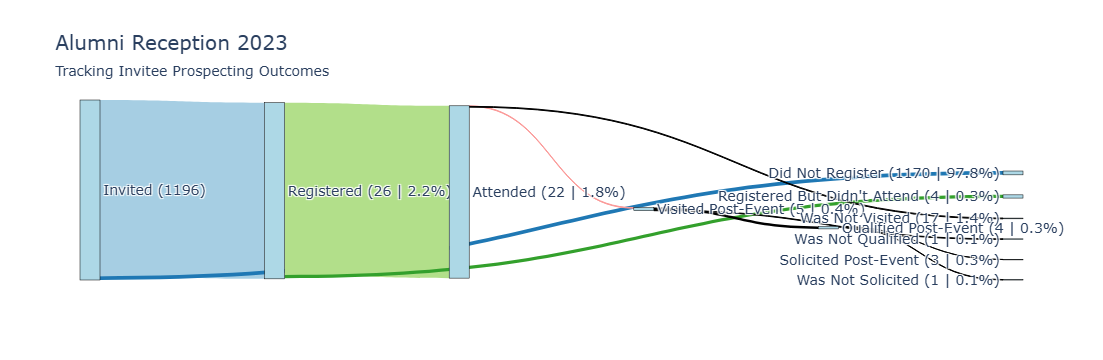

In [8]:
# Sankey diagram with enhanced hover tooltips
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=percent_labels,
        color="lightblue"
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        #hovertemplate=custom_tooltips,
        color=["#a6cee3", "#1f78b4", "#b2df8a", "#33a02c", "#fb9a99"]
    )
)])

fig.update_layout(
    title_text="Alumni Reception 2023", 
    title_xanchor="auto",
    title_subtitle_text="Tracking Invitee Prospecting Outcomes",
    font_size=14)
fig.show()